In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. ANÁLISE EXPLORATÓRIA DE DADOS

In [28]:
df = pd.read_csv('manutencao_preditiva.csv')

In [29]:
#Dimensoes do dataset:
num_linhas, num_colunas = df.shape
print(f"O dataset possui {num_linhas} linhas e {num_colunas} colunas.")

O dataset possui 10000 linhas e 14 colunas.


In [30]:
# Tipos de dados das variáveis:

display(df.dtypes)
print("Tipos de dados das variáveis:")

udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Tipos de dados das variáveis:


In [31]:
#Resumo estatístico das colunas numéricas usando ".describe()":
display(df.describe())
print("Resumo estatístico descritivo:")


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Resumo estatístico descritivo:


1.2. ANÁLISE GRÁFICA

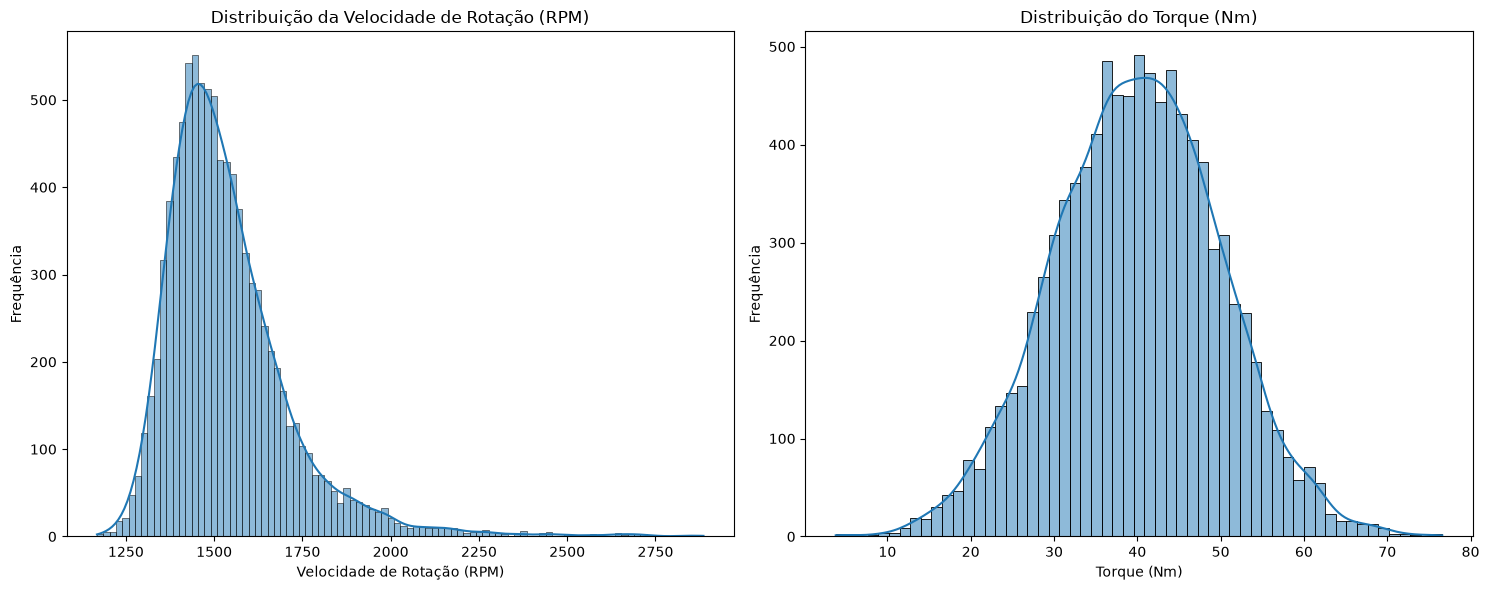

In [32]:
#HISTOGRAMA PARA DEMONSTRAÇÃO DA DISTRIBUIÇÃO DE VARIÁVEIS PREDITORAS:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['velocidade_rotacao_rpm'].dropna(), kde=True)
plt.title('Distribuição da Velocidade de Rotação (RPM)')
plt.xlabel('Velocidade de Rotação (RPM)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.histplot(df['torque_nm'].dropna(), kde=True)
plt.title('Distribuição do Torque (Nm)')
plt.xlabel('Torque (Nm)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

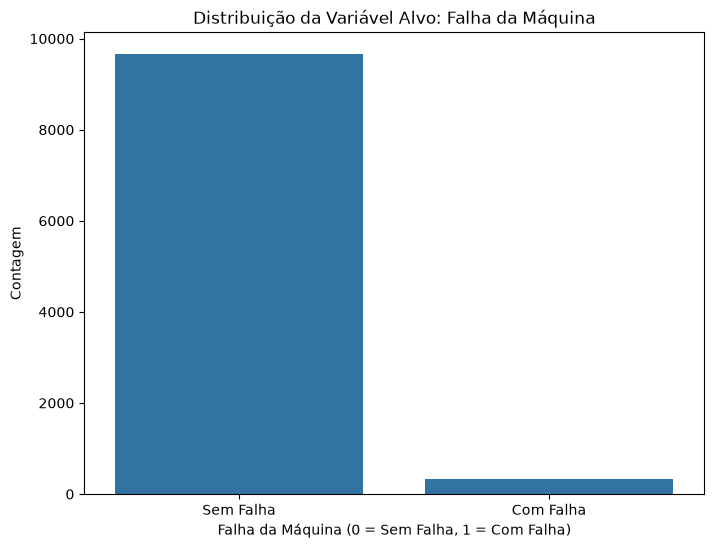

Porcentagem de máquinas sem falha: 96.61%
Porcentagem de máquinas com falha: 3.39%


In [33]:
#GRÁFICO BARRAS PARA DEMONSTRAR O DESBALANCEAMENTO DA VARIÁVEL ALVO:

plt.figure(figsize=(8, 6))
sns.countplot(x='falha_maquina', data=df)
plt.title('Distribuição da Variável Alvo: Falha da Máquina')
plt.xlabel('Falha da Máquina (0 = Sem Falha, 1 = Com Falha)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Sem Falha', 'Com Falha'])
plt.show()

falha_counts = df['falha_maquina'].value_counts(normalize=True) * 100
print(f"Porcentagem de máquinas sem falha: {falha_counts[0]:.2f}%")
print(f"Porcentagem de máquinas com falha: {falha_counts[1]:.2f}%")

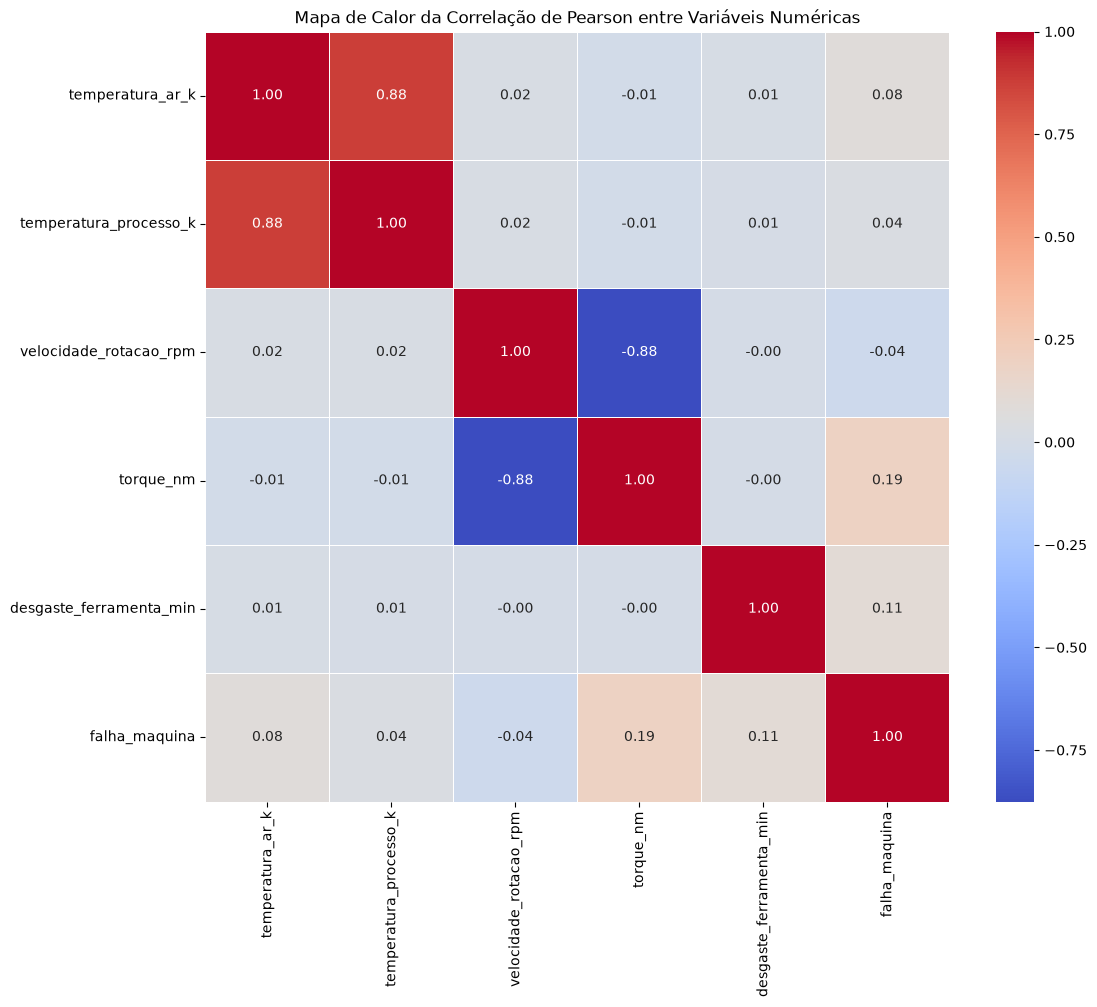

In [34]:
# MAPA DE CALOR - CORRELAÇÃO DE PEARSON:
# Excluídas as colunas de identificação (udi, id_produto) e colunas de falha que não são a variável alvo.

columns_to_exclude = ['udi', 'id_produto', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']

df_corr = df.drop(columns=columns_to_exclude, errors='ignore')

# Selecionar apenas colunas numéricas para a correlação
df_numeric = df_corr.select_dtypes(include=['number'])

correlation_matrix = df_numeric.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas')
plt.show()

Conclusões sobre os gráficos previamente gerados:
1. As curvas de "sino" mostram a distribuição normal (estatística) de velocidade de rotação e torque com picos em baixa frequência, como esperado, pois faz sentido que máquinas operem em condições normais, não em extremos, o que certamente causaria maior desgaste e falhas, por consequência. 
2. O gráfico de barras comprova a estabilidade na operação, com uma taxa de falha abaixo de 4%.
3. Para este modelo, a correlação de Pearson apresenta alguma relação da variável alvo com o torque, mas as demais correlações que seriam consideradas importantes por estarem próximas de "1", são óbvias, e não trazem informação relevante.   

2. DATA PREP - LIMPEZA E TRATAMENTO DE DADOS

In [35]:
# Remover linhas duplicadas
linhas_duplicadas = df.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {linhas_duplicadas}")

if linhas_duplicadas > 0:
    df_cleaned = df.drop_duplicates().copy()
    print(f"Número de linhas após a remoção de duplicadas: {len(df_cleaned)}")
else:
    df_cleaned = df.copy()
    print("Nenhuma linha duplicada encontrada.")

# Para atualizar o DataFrame principal
df = df_cleaned 


Número de linhas duplicadas encontradas: 0
Nenhuma linha duplicada encontrada.


Dados ausentes por coluna:


temperatura_ar_k          500
temperatura_processo_k    500
velocidade_rotacao_rpm    500
torque_nm                 500
dtype: int64

Imputando dados ausentes em colunas numéricas...


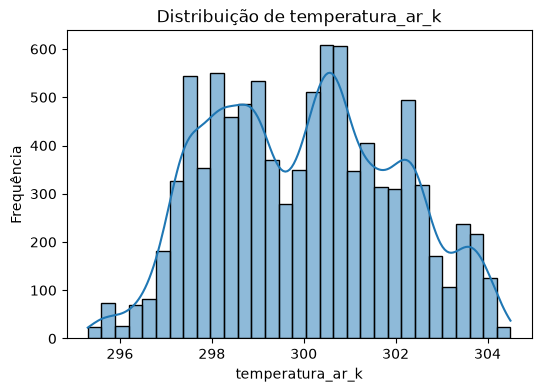

Assimetria da coluna 'temperatura_ar_k': 0.11
Dados ausentes na coluna 'temperatura_ar_k' completados com a MÉDIA devido à distribuição simétrica.


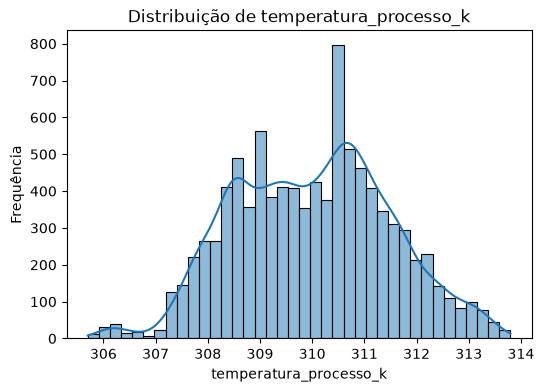

Assimetria da coluna 'temperatura_processo_k': 0.02
Dados ausentes na coluna 'temperatura_processo_k' completados com a MÉDIA devido à distribuição simétrica.


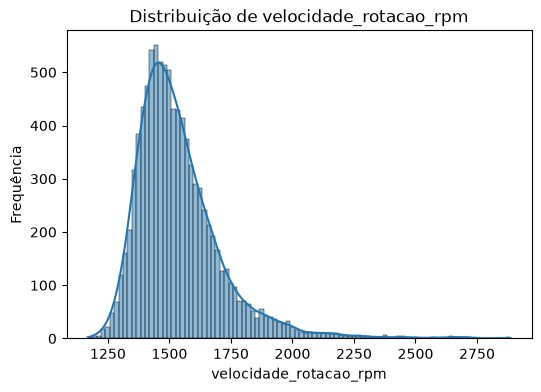

Assimetria da coluna 'velocidade_rotacao_rpm': 1.99
Dados ausentes na coluna 'velocidade_rotacao_rpm' completados com a MEDIANA devido à distribuição assimétrica.


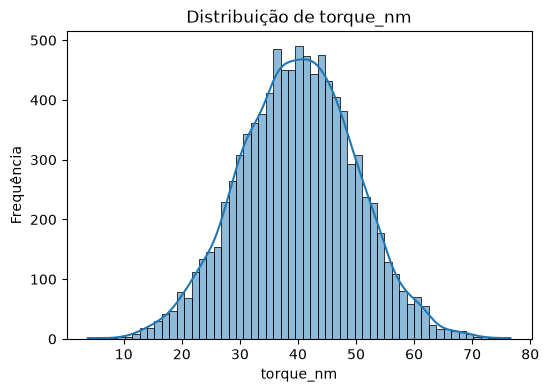

Assimetria da coluna 'torque_nm': -0.01
Dados ausentes na coluna 'torque_nm' completados com a MÉDIA devido à distribuição simétrica.
Verificação final de dados ausentes:


udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

In [36]:
# Tratar dados ausentes, preenchendo com a média ou mediana.

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

print("Dados ausentes por coluna:")
if not missing_data.empty:
    display(missing_data)

    # Imputar dados ausentes em colunas numéricas
    numeric_cols_with_missing = df[missing_data.index].select_dtypes(include=['number']).columns

    if not numeric_cols_with_missing.empty:
        print("Imputando dados ausentes em colunas numéricas...")
        for col in numeric_cols_with_missing:
            # Plotar distribuição para aplicar Média ou Mediana
            plt.figure(figsize=(6, 4))
            sns.histplot(df[col].dropna(), kde=True)
            plt.title(f'Distribuição de {col}')
            plt.xlabel(col)
            plt.ylabel('Frequência')
            plt.show()

            # Verificando assimetria
            assimetria = df[col].skew()
            print(f"Assimetria da coluna '{col}': {assimetria:.2f}")

            if abs(assimetria) > 0.5:  # Parâmetro que indica assimetria significativa
                df[col] = df[col].fillna(df[col].median())
                print(f"Dados ausentes na coluna '{col}' completados com a MEDIANA devido à distribuição assimétrica.")
            else:
                df[col] = df[col].fillna(df[col].mean())
                print(f"Dados ausentes na coluna '{col}' completados com a MÉDIA devido à distribuição simétrica.")
    else:
        print("Não há colunas numéricas com dados ausentes.")

    # Imputar dados ausentes em colunas categóricas com a moda
    categorical_cols_with_missing = df[missing_data.index].select_dtypes(include=['object']).columns

    if not categorical_cols_with_missing.empty:
        print("Imputando dados ausentes em colunas categóricas com a MODA...")
        for col in categorical_cols_with_missing:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"Dados ausentes na coluna '{col}' imputados com a MODA: {mode_val}.")

else:
    print("Nenhum dado ausente encontrado.")

print("Verificação final de dados ausentes:")
display(df.isnull().sum())

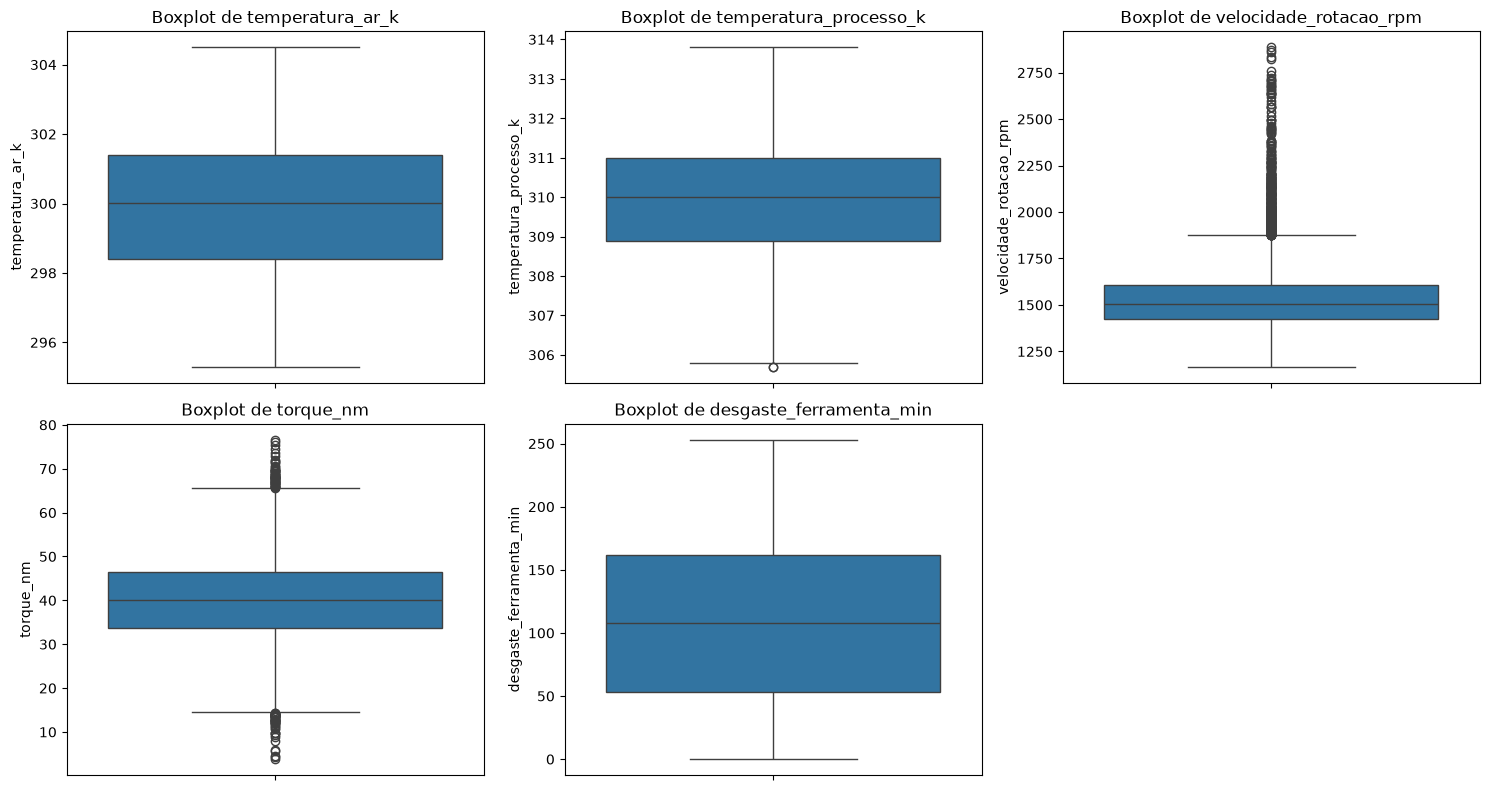

In [37]:
#GRAFICO BOXPLOT - IDENTIFICAÇÃO DE OUTLIERS

# Considerar somente colunas numéricas explicativas e excluir colunas de id, alvo e outras falhas de caráter informativo
explanatory_numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

exclude_for_outliers = ['udi', 'id_produto', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
explanatory_numeric_cols = [col for col in explanatory_numeric_cols if col not in exclude_for_outliers]

if not explanatory_numeric_cols:
    print("Nenhuma coluna numérica explicativa encontrada para plotar boxplots.")
else:
    # Criar boxplots para as variáveis numéricas explicativas
    num_plots = len(explanatory_numeric_cols)
    # Ajuste do tamanho da figura e layout para 3 colunas de subplots    
    num_cols_grid = 3
    num_rows_grid = (num_plots + num_cols_grid - 1) // num_cols_grid

    plt.figure(figsize=(5 * num_cols_grid, 4 * num_rows_grid))

    for i, col in enumerate(explanatory_numeric_cols):
        plt.subplot(num_rows_grid, num_cols_grid, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot de {col}')
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

3. FEATURE ENGINEERING 
obs.: dados nulos e ausentes já foram tratados previamente

In [38]:
# Criando uma variável Potência:

df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']
print("Coluna 'potencia' criada com sucesso.")
display(df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head())

Coluna 'potencia' criada com sucesso.


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.800000,66382.800000
1,1408.0,46.300000,65190.400000
2,1498.0,49.400000,74001.200000
3,1504.0,39.974168,60121.149305
4,1408.0,40.000000,56320.000000


4. DIVISÃO E BALANCEAMENTO DE DADOS

4.1 Separando as Variáveis Preditoras (X) e Alvo (y)

In [39]:
# Variável alvo
y = df['falha_maquina']

# Variáveis preditoras (X)
# Excluir 'udi', 'id_produto', 'falha_maquina' e as demais colunas de falha
columns_to_drop_from_X = ['udi', 'id_produto', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
X = df.drop(columns=columns_to_drop_from_X, errors='ignore')

# Aplicar One-Hot Encoding para a coluna 'tipo' (que é categórica)
X = pd.get_dummies(X, columns=['tipo'], drop_first=True)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)
print("Primeiras linhas de X (após one-hot encoding e exclusão de colunas):")
display(X.head())

Dimensões de X: (10000, 8)
Dimensões de y: (10000,)
Primeiras linhas de X (após one-hot encoding e exclusão de colunas):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia,tipo_L,tipo_M
0,298.100000,308.600000,1551.0,42.800000,0,66382.800000,False,True
1,298.200000,308.700000,1408.0,46.300000,3,65190.400000,True,False
2,298.100000,308.500000,1498.0,49.400000,5,74001.200000,True,False
3,300.002158,310.000895,1504.0,39.974168,7,60121.149305,True,False
4,298.200000,308.700000,1408.0,40.000000,9,56320.000000,True,False


4.2 Separando os Dados em Conjuntos de Treino e Teste

In [40]:
from sklearn.model_selection import train_test_split

# Dividir os dados em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

print("Distribuição da variável alvo em y_train:")
display(y_train.value_counts(normalize=True))
print("Distribuição da variável alvo em y_test:")
display(y_test.value_counts(normalize=True))

Dimensões de X_train: (8000, 8)
Dimensões de X_test: (2000, 8)
Dimensões de y_train: (8000,)
Dimensões de y_test: (2000,)
Distribuição da variável alvo em y_train:


falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Distribuição da variável alvo em y_test:


falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64

4.3 REAMOSTRAGEM COM SMOTE (Apenas nos dados de treino para evitar Data Leakage)

In [41]:
from imblearn.over_sampling import SMOTE

# Instanciar o SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE APENAS nos dados de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição da variável alvo no y_train original:")
display(y_train.value_counts())
print("Distribuição da variável alvo no y_train reamostrado com SMOTE:")
display(y_train_resampled.value_counts())

ModuleNotFoundError: No module named 'imblearn'